<a href="https://colab.research.google.com/github/gunjan1853/AI_ML/blob/main/Deep_Learning/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [ ]:
dataset = load_dataset("dair-ai/emotion")

print(dataset)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [ ]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (16000, 2)
Validation: (2000, 2)
Test: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
print(train_df["label"].value_counts().sort_index())

label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64


In [ ]:
emotion_names = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
]

train_df["emotion"] = train_df["label"].apply(
    lambda x: emotion_names[x]
)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
X_train = train_df["text"].values
y_train = train_df["label"].values

X_val = val_df["text"].values
y_val = val_df["label"].values

X_test = test_df["text"].values
y_test = test_df["label"].values

print(X_train[:5])
print(y_train[:5])

['i didnt feel humiliated'
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'
 'im grabbing a minute to post i feel greedy wrong'
 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property'
 'i am feeling grouchy']
[0 0 3 2 3]


In [ ]:
MAX_WORDS = 10000
MAX_LENGTH = 50

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Original:")
print(X_train[0])

print("\nTokenized:")
print(X_train_seq[0])

Original:
i didnt feel humiliated

Tokenized:
[2, 139, 3, 679]


In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

Train shape: (16000, 50)
Validation shape: (2000, 50)
Test shape: (2000, 50)


In [ ]:
model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=64
    ),

    GlobalAveragePooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(6, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3275 - loss: 1.6099 - val_accuracy: 0.3520 - val_loss: 1.5752 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3514 - loss: 1.5258 - val_accuracy: 0.3805 - val_loss: 1.3762 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5131 - loss: 1.1787 - val_accuracy: 0.6175 - val_loss: 1.0298 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6596 - loss: 0.8630 - val_accuracy: 0.6870 - val_loss: 0.8048 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7523 - loss: 0.6287 - val_accuracy: 0.7285 - val_loss: 0.6549 - learning_rate: 0.0010
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7852 - loss: 0.5216 - val_accuracy: 0.7410 - val_loss: 0.7297 - learning_rate: 0.0010
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8219 - loss: 0.4356 - 

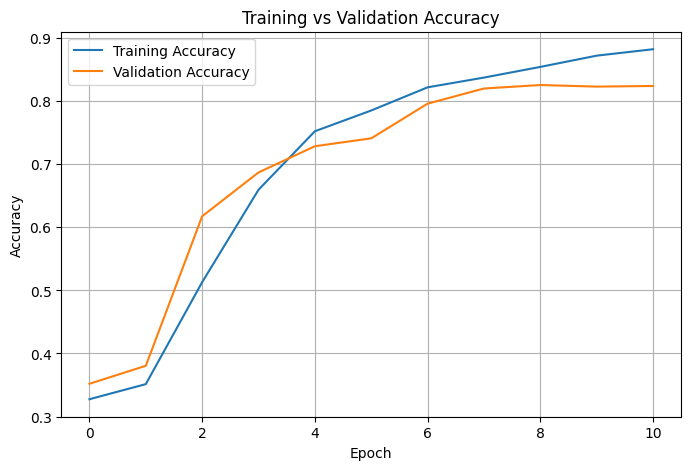

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

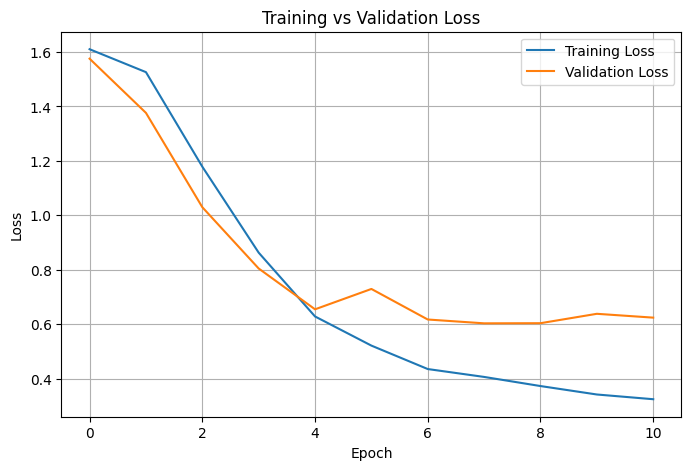

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.5689855813980103
Test Accuracy: 0.8215000033378601


In [ ]:
y_pred_prob = model.predict(X_test_pad)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("Actual:", y_test[:10])
print("Predicted:", y_pred[:10])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Actual: [0 0 0 1 0 4 3 1 1 3]
Predicted: [0 0 0 1 0 3 3 1 1 3]


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=emotion_names
    )
)

              precision    recall  f1-score   support

     sadness       0.94      0.90      0.92       581
         joy       0.91      0.92      0.91       695
        love       0.65      0.70      0.67       159
       anger       0.65      0.74      0.69       275
        fear       0.66      0.66      0.66       224
    surprise       0.62      0.23      0.33        66

    accuracy                           0.82      2000
   macro avg       0.74      0.69      0.70      2000
weighted avg       0.82      0.82      0.82      2000



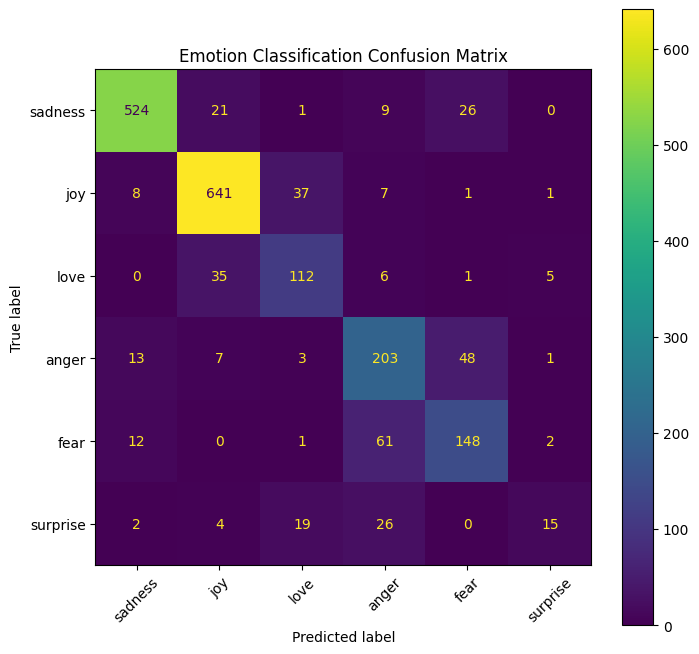

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=emotion_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Emotion Classification Confusion Matrix")
plt.show()

In [ ]:
def predict_emotion(text):

    sequence = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probabilities = model.predict(
        padded,
        verbose=0
    )[0]

    predicted_class = np.argmax(probabilities)

    emotion = emotion_names[predicted_class]

    confidence = probabilities[predicted_class] * 100

    return emotion, confidence

In [ ]:
texts = [
    "I am extremely happy today!",
    "I lost my best friend and I feel terrible.",
    "I am so angry with him.",
    "I am scared about what will happen.",
    "I really love this person.",
    "Wow! I did not expect that!"
]

for text in texts:
    emotion, confidence = predict_emotion(text)

    print("\nText:", text)
    print("Emotion:", emotion)
    print(f"Confidence: {confidence:.2f}%")


Text: I am extremely happy today!
Emotion: joy
Confidence: 80.07%

Text: I lost my best friend and I feel terrible.
Emotion: sadness
Confidence: 99.82%

Text: I am so angry with him.
Emotion: anger
Confidence: 51.03%

Text: I am scared about what will happen.
Emotion: fear
Confidence: 55.74%

Text: I really love this person.
Emotion: sadness
Confidence: 46.55%

Text: Wow! I did not expect that!
Emotion: sadness
Confidence: 51.59%


In [ ]:
def emotion_probabilities(text):

    sequence = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probabilities = model.predict(
        padded,
        verbose=0
    )[0]

    result = pd.DataFrame({
        "Emotion": emotion_names,
        "Probability": probabilities
    })

    result["Probability"] = result["Probability"] * 100

    return result.sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

In [ ]:
text = "I am nervous because my exam is tomorrow."

emotion_probabilities(text)

,Emotion,Probability
0,fear,56.663902
1,anger,42.241707
2,surprise,0.561684
3,sadness,0.474674
4,love,0.056984
5,joy,0.001048


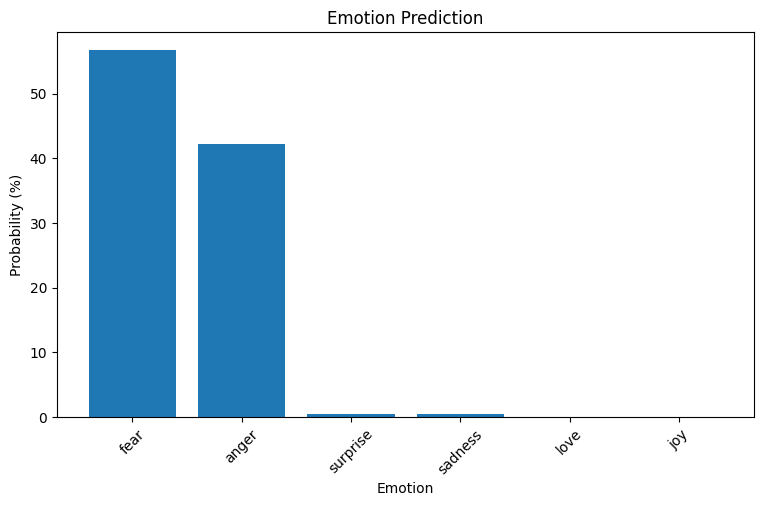

In [ ]:
result = emotion_probabilities(
    "I am nervous because my exam is tomorrow."
)

plt.figure(figsize=(9, 5))

plt.bar(
    result["Emotion"],
    result["Probability"]
)

plt.xlabel("Emotion")
plt.ylabel("Probability (%)")
plt.title("Emotion Prediction")

plt.xticks(rotation=45)
plt.show()

In [ ]:
model.save("emotion_ann_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import pickle

with open("emotion_tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!
